# **Section 1: Setting up Kaggle API and downloading datasets**
### This section sets up the Kaggle API, downloads two brain tumor datasets from Kaggle, and unzips them.

In [ ]:
!mkdir -p ~/.kaggle

In [ ]:
!cp kaggle.json.json ~/.kaggle/

cp: cannot stat 'kaggle.json.json': No such file or directory


In [ ]:
!kaggle datasets download -d ahmedhamada0/brain-tumor-detection

Dataset URL: https://www.kaggle.com/datasets/ahmedhamada0/brain-tumor-detection
License(s): copyright-authors
 95% 80.0M/84.0M [00:01<00:00, 49.4MB/s]
100% 84.0M/84.0M [00:01<00:00, 45.9MB/s]


In [ ]:
!chmod 600 /root/.kaggle/kaggle.json

chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!unzip "/content/brain-tumor-detection.zip"

Archive:  /content/brain-tumor-detection.zip
  inflating: Br35H-Mask-RCNN/TEST/annotations_test.json  
  inflating: Br35H-Mask-RCNN/TEST/y701.jpg  
  inflating: Br35H-Mask-RCNN/TEST/y702.jpg  
  inflating: Br35H-Mask-RCNN/TEST/y703.jpg  
  inflating: Br35H-Mask-RCNN/TEST/y704.jpg  
  inflating: Br35H-Mask-RCNN/TEST/y705.jpg  
  inflating: Br35H-Mask-RCNN/TEST/y706.jpg  
  inflating: Br35H-Mask-RCNN/TEST/y707.jpg  
  inflating: Br35H-Mask-RCNN/TEST/y708.jpg  
  inflating: Br35H-Mask-RCNN/TEST/y709.jpg  
  inflating: Br35H-Mask-RCNN/TEST/y710.jpg  
  inflating: Br35H-Mask-RCNN/TEST/y711.jpg  
  inflating: Br35H-Mask-RCNN/TEST/y712.jpg  
  inflating: Br35H-Mask-RCNN/TEST/y713.jpg  
  inflating: Br35H-Mask-RCNN/TEST/y714.jpg  
  inflating: Br35H-Mask-RCNN/TEST/y715.jpg  
  inflating: Br35H-Mask-RCNN/TEST/y716.jpg  
  inflating: Br35H-Mask-RCNN/TEST/y717.jpg  
  inflating: Br35H-Mask-RCNN/TEST/y718.jpg  
  inflating: Br35H-Mask-RCNN/TEST/y719.jpg  
  inflating: Br35H-Mask-RCNN/TEST/y720.jpg

In [ ]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): CC0-1.0
100% 148M/149M [00:02<00:00, 86.1MB/s]
100% 149M/149M [00:02<00:00, 71.6MB/s]


In [ ]:
!unzip "/content/brain-tumor-mri-dataset.zip"

Streaming output truncated to the last 5000 lines.
  inflating: Training/glioma/Tr-gl_0712.jpg  
  inflating: Training/glioma/Tr-gl_0713.jpg  
  inflating: Training/glioma/Tr-gl_0714.jpg  
  inflating: Training/glioma/Tr-gl_0715.jpg  
  inflating: Training/glioma/Tr-gl_0716.jpg  
  inflating: Training/glioma/Tr-gl_0717.jpg  
  inflating: Training/glioma/Tr-gl_0718.jpg  
  inflating: Training/glioma/Tr-gl_0719.jpg  
  inflating: Training/glioma/Tr-gl_0720.jpg  
  inflating: Training/glioma/Tr-gl_0721.jpg  
  inflating: Training/glioma/Tr-gl_0722.jpg  
  inflating: Training/glioma/Tr-gl_0723.jpg  
  inflating: Training/glioma/Tr-gl_0724.jpg  
  inflating: Training/glioma/Tr-gl_0725.jpg  
  inflating: Training/glioma/Tr-gl_0726.jpg  
  inflating: Training/glioma/Tr-gl_0727.jpg  
  inflating: Training/glioma/Tr-gl_0728.jpg  
  inflating: Training/glioma/Tr-gl_0729.jpg  
  inflating: Training/glioma/Tr-gl_0730.jpg  
  inflating: Training/glioma/Tr-gl_0731.jpg  
  inflating: Training/glioma/

# **Section 2: Importing necessary libraries and preparing the data**
### This section imports essential libraries and prepares the dataset for training, validation, and testing.

In [ ]:
# System and file management
import os
import shutil
import random

# Data processing and model evaluation
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# TensorFlow and Keras for deep learning
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Keras models and layers
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, ZeroPadding2D, Activation, GlobalAveragePooling2D, BatchNormalization
from keras import models, layers, optimizers, backend as K

# OpenCV for image processing
import cv2

## Displaying the number of images in each category within the Training folder

In [ ]:
len(os.listdir("/content/Training/glioma")),len(os.listdir("/content/Training/meningioma")),len(os.listdir("/content/Training/pituitary")),len(os.listdir("/content/Training/notumor"))

(1321, 1339, 1457, 1595)

## Moving dataset into 'yes' and 'no' folders for binary classification

In [ ]:
# Moving glioma, meningioma, and pituitary tumor images to 'yes' folder (indicating presence of tumor)
for im_name in os.listdir("/content/Training/glioma"):
  shutil.copyfile(src="/content/Training/glioma/"+im_name ,dst="/content/yes/"+im_name)

for im_name in os.listdir("/content/Training/meningioma"):
  shutil.copyfile(src="/content/Training/meningioma/"+im_name ,dst="/content/yes/"+im_name)

for im_name in os.listdir("/content/Training/pituitary"):
  shutil.copyfile(src="/content/Training/pituitary/"+im_name ,dst="/content/yes/"+im_name)

# # Moving 'notumor' images to 'no' folder (indicating absence of tumor)
for im_name in os.listdir("/content/Training/notumor"):
  shutil.copyfile(src="/content/Training/notumor/"+im_name ,dst="/content/no/"+im_name)

In [ ]:
len(os.listdir("/content/Testing/glioma")),len(os.listdir("/content/Testing/meningioma")),len(os.listdir("/content/Testing/pituitary")),len(os.listdir("/content/Testing/notumor"))

(300, 306, 300, 405)

In [ ]:
for im_name in os.listdir("/content/Testing/glioma"):
  shutil.copyfile(src="/content/Testing/glioma/"+im_name ,dst="/content/yes/"+im_name)

for im_name in os.listdir("/content/Testing/meningioma"):
  shutil.copyfile(src="/content/Testing/meningioma/"+im_name ,dst="/content/yes/"+im_name)

for im_name in os.listdir("/content/Testing/pituitary"):
  shutil.copyfile(src="/content/Testing/pituitary/"+im_name ,dst="/content/yes/"+im_name)

for im_name in os.listdir("/content/Testing/notumor"):
  shutil.copyfile(src="/content/Testing/notumor/"+im_name ,dst="/content/no/"+im_name)

## Creating directory structure for train, validation, and test sets

In [ ]:
# Make file  dataset
os.mkdir("/content/Dataset")

# Training directory
os.mkdir("/content/Dataset/training")

os.mkdir("/content/Dataset/training/no")
os.mkdir("/content/Dataset/training/yes")

In [ ]:
# Validation directory
os.mkdir("/content/Dataset/validation")

os.mkdir("/content/Dataset/validation/no")
os.mkdir("/content/Dataset/validation/yes")

In [ ]:
# Test directory

os.mkdir("/content/Dataset/test")

os.mkdir("/content/Dataset/test/no")
os.mkdir("/content/Dataset/test/yes")

# **Section 3: Splitting data into train, validation, and test sets**
### This section splits the data into training, validation, and testing sets and copies the images into their respective directories.

In [ ]:
# Get list of all images in 'yes' and 'no' folders
no_data=os.listdir("/content/no") # List of images names of no_data
yes_data=os.listdir("/content/yes") # List of images names of yes_data

# Shuffle the data
random.shuffle(no_data)
random.shuffle(yes_data)

# Split the data into training, validation, and test sets (80% train, 20% validation + test)
training_no, val_andtest_no = train_test_split(no_data, test_size=0.2, random_state=25)
training_yes, val_andtest_yes = train_test_split(yes_data, test_size=0.2, random_state=25)

# Further split validation and test sets (50% validation, 50% test)
test_yes, val_yes = train_test_split(val_andtest_yes, test_size=0.5, random_state=25)
test_no, val_no = train_test_split(val_andtest_no, test_size=0.5, random_state=25)


# Copying training images to respective directories
for im_name in training_no:
  shutil.copyfile(src="/content/no/"+im_name ,dst="/content/Dataset/training/no/"+im_name)

for im_name in val_no:
  shutil.copyfile(src="/content/no/"+im_name ,dst="/content/Dataset/validation/no/"+im_name)


for im_name in training_yes:
  shutil.copyfile(src="/content/yes/"+im_name ,dst="/content/Dataset/training/yes/"+im_name)

for im_name in val_yes:
  shutil.copyfile(src="/content/yes/"+im_name ,dst="/content/Dataset/validation/yes/"+im_name)


# Copying test images to respective directories
for im_name in test_no:
  shutil.copyfile(src="/content/no/"+im_name ,dst="/content/Dataset/test/no/"+im_name)

for im_name in test_yes:
  shutil.copyfile(src="/content/yes/"+im_name ,dst="/content/Dataset/test/yes/"+im_name)

# **Section 4: Verifying the number of images in each directory**
### This section prints the number of images in each category of the train, validation, and test sets to ensure correct distribution.

In [ ]:
print("num_training--->no")
print(len(os.listdir("/content/Dataset/training/no")))
print("num_training----->yes")
print(len(os.listdir("/content/Dataset/training/yes")))

print("num_validation---->no")
print(len(os.listdir("/content/Dataset/validation/no")))
print("num_validation---->yes")
print(len(os.listdir("/content/Dataset/validation/yes")))

print("num_test---->yes")
print(len(os.listdir("/content/Dataset/test/yes/")))
print("num_test---->no")
print(len(os.listdir("/content/Dataset/test/no/")))

num_training--->no
2800
num_training----->yes
5218
num_validation---->no
350
num_validation---->yes
653
num_test---->yes
652
num_test---->no
350


# **Section 5: Data preparation and augmentation**
### This section creates ImageDataGenerator objects for data preprocessing and augmentation.

In [ ]:
# Data augmentation and rescaling for training data
train_datagen = ImageDataGenerator(
      rescale=1./255)

# Only rescaling for validation and test data (no augmentation)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Creating data generators for train, validation, and test sets
train_generator = train_datagen.flow_from_directory(
    '/content/Dataset/training',
    # Images  resized to 224*224
    target_size=(224, 224),
    batch_size=64,
    shuffle=True,
    class_mode='binary')

validation_generator = val_datagen.flow_from_directory(
    '/content/Dataset/validation',
    target_size=(224, 224),
    batch_size=64,
    shuffle=True,
    class_mode='binary')

test_generator = test_datagen.flow_from_directory(
    '/content/Dataset/test',
    # Images  resized to 224*224
    target_size=(224, 224),
    batch_size=64,
    shuffle=False,
    class_mode='binary')

Found 8018 images belonging to 2 classes.
Found 1003 images belonging to 2 classes.
Found 1002 images belonging to 2 classes.


# **Section 6: Building the CNN model**
### This section defines and compiles the convolutional neural network model for binary classification.

In [ ]:
# Create a sequential model
model = Sequential()

# Adding convolutional layers and pooling layers
model.add(Conv2D(filters=128, kernel_size=(3,3), strides=(2,2), activation='relu', input_shape=(224,224,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters=128, kernel_size=(5,5)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=96, kernel_size=(2,2)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2) ))

model.add(Conv2D(filters=96, kernel_size=(3,3), strides=(1,1), padding='valid'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=96, kernel_size=(3,3)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Activation('relu'))

# Flattening the output and adding dense layers
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(50, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(), metrics=['acc'])

# Print the model summary
model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 111, 111, 128)       │           3,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 111, 111, 128)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 55, 55, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 51, 51, 128)         │         409,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 51, 51, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 25, 25, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 24, 24, 96)          │          49,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 24, 24, 96)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 12, 12, 96)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 10, 10, 96)          │          83,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 10, 10, 96)          │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 10, 10, 96)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 5, 5, 96)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 3, 3, 96)            │          83,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 1, 1, 96)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 1, 1, 96)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 96)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 50)                  │           6,450 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 647,941 (2.47 MB)

 Trainable params: 647,749 (2.47 MB)

 Non-trainable params: 192 (768.00 B)

# **Section 7: Training the model and saving the best model**
### This section trains the CNN model and saves the best model based on validation accuracy.


In [ ]:
# Model checkpoint to save the best model
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    '/content/bestmodel/model-{epoch:03d}-{acc:03f}-{val_acc:03f}.keras',  # Change file extension to .keras
    verbose=1,
    monitor='val_loss',
    save_best_only=True,
    mode='auto'
)

In [ ]:
# Train the model
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    callbacks=[checkpoint]
)

Epoch 1/30


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - acc: 0.7995 - loss: 0.4164
Epoch 1: val_loss improved from inf to 0.72016, saving model to /content/bestmodel/model-001-0.850836-0.666999.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 45s 260ms/step - acc: 0.7999 - loss: 0.4158 - val_acc: 0.6670 - val_loss: 0.7202
Epoch 2/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - acc: 0.9278 - loss: 0.1834
Epoch 2: val_loss improved from 0.72016 to 0.27243, saving model to /content/bestmodel/model-002-0.934647-0.883350.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 29s 222ms/step - acc: 0.9279 - loss: 0.1833 - val_acc: 0.8833 - val_loss: 0.2724
Epoch 3/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - acc: 0.9613 - loss: 0.1104
Epoch 3: val_loss improved from 0.27243 to 0.20142, saving model to /content/bestmodel/model-003-0.964455-0.928215.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 33s 245ms/step - acc: 0.9614 - loss: 0.1103 - val_acc: 0.9282 - val_loss: 0.2014
Epoch 4/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - acc: 0.9750 - los

In [ ]:
# List the saved models in the directory
model_files = os.listdir("/content/bestmodel")

In [ ]:
import os
import re
import tensorflow as tf

# Find the model file with the highest validation accuracy
best_model = max(model_files, key=lambda x: float(re.search(r"-(\d+\.\d+)\.keras", x).group(1)))

# Load the best model based on validation accuracy
best_model_path = os.path.join("/content/bestmodel", best_model)
model = tf.keras.models.load_model(best_model_path)

print(f"Loaded the best model: {best_model}")

Loaded the best model: model-012-0.999875-0.989033.keras


# **Section 8: Model evaluation and performance visualization**
### This section evaluates the model on the test set and visualizes the training and validation accuracy and loss.

In [ ]:
# Evaluate the model on the test set
results = model.evaluate(test_generator)
print("test loss, test acc:", results)

16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 382ms/step - acc: 0.9897 - loss: 0.0430
test loss, test acc: [0.021386507898569107, 0.9940119981765747]


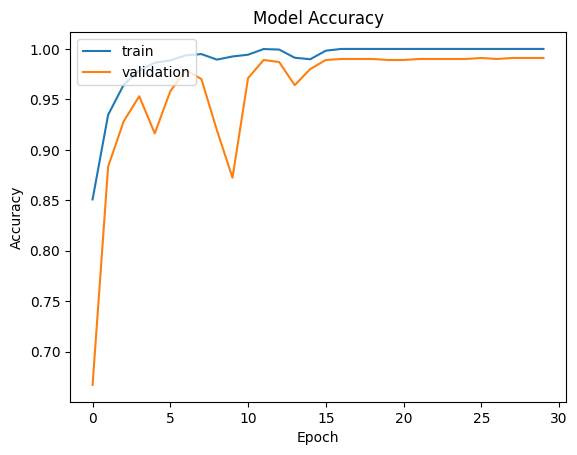

In [ ]:
# Plotting training and validation accuracy
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

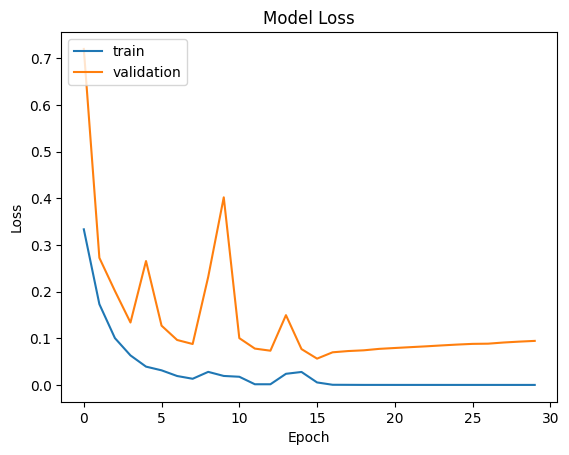

In [ ]:
# Plotting training and validation loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

# **Section 9: Making predictions and evaluating model performance on test set**
### This section contains a function to make predictions and evaluates the model's performance using classification metrics.


In [ ]:
# Function to predict tumor presence in an image
def model_prediction(im_path):
  im = cv2.imread(im_path)
  im = cv2.resize(im, (224, 224))
  im = cv2.cvtColor(im, cv2.COLOR_RGB2BGR)
  im = (im.astype(np.float32)) / 255.0
  im = im[np.newaxis, ...]
  predicted = model.predict(im)
  if predicted > 0.49:
      return 1
  if predicted < 0.50:
      return 0

In [ ]:
# Making predictions on the test set
real=[]
prediction=[]
for imgs in os.listdir("/content/Dataset/test/yes"):
  real.append(1)
  result=model_prediction("/content/Dataset/test/yes/"+imgs)
  prediction.append(result)

for imgs in os.listdir("/content/Dataset/test/no"):
  real.append(0)
  result=model_prediction("/content/Dataset/test/no/"+imgs)
  prediction.append(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 784ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━

In [ ]:
# Convert predictions and real labels to NumPy arrays
prediction = np.array(prediction)
real = np.array(real)

In [ ]:
# Print classification report
print(classification_report(real, prediction))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       350
           1       0.99      1.00      0.99       652

    accuracy                           0.99      1002
   macro avg       0.99      0.99      0.99      1002
weighted avg       0.99      0.99      0.99      1002



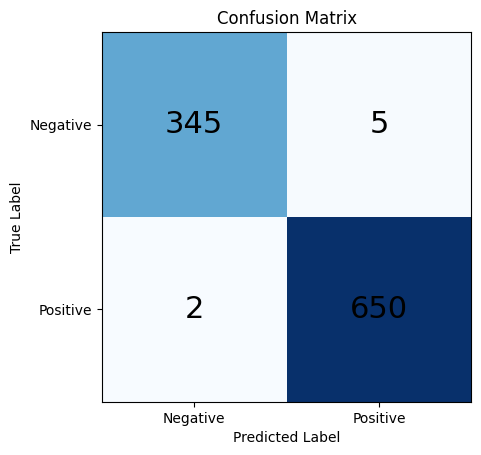

In [ ]:
# Plot confusion matrix
cm = confusion_matrix(real, prediction)
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xticks(ticks=[0,1], labels=['Negative', 'Positive'])
plt.yticks(ticks=[0,1], labels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black', fontsize=22)
plt.show()

In [ ]:
# Save the model
model.save('tumor_mixed_dataset.h5')

# **Section 10: Model performance evaluation on the validation set**
### This section evaluates the model on the validation set using the prediction function defined earlier.

In [ ]:
# Making predictions on the validation set
real=[]
prediction=[]
for imgs in os.listdir("/content/Dataset/validation/yes") :
  real.append(1)
  result=model_prediction("/content/Dataset/validation/yes/"+imgs)
  prediction.append(result)

for imgs in os.listdir("/content/Dataset/validation/no") :
  real.append(0)
  result=model_prediction("/content/Dataset/validation/no/"+imgs)
  prediction.append(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━

In [ ]:
# Convert predictions and real labels to NumPy arrays
prediction = np.array(prediction)
real = np.array(real)

In [ ]:
# Print classification report
print(classification_report(real, prediction))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       350
           1       0.99      0.99      0.99       653

    accuracy                           0.99      1003
   macro avg       0.99      0.99      0.99      1003
weighted avg       0.99      0.99      0.99      1003



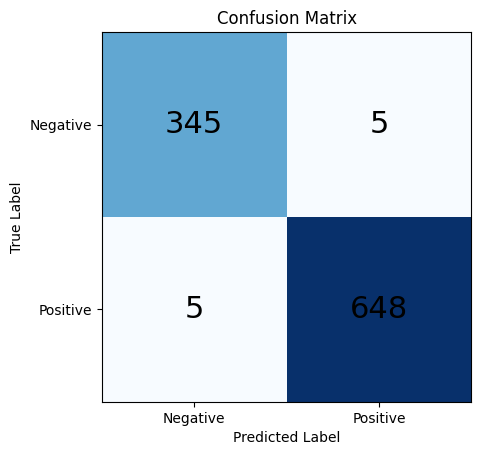

In [ ]:
# Plot confusion matrix
cm = confusion_matrix(real, prediction)
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xticks(ticks=[0,1], labels=['Negative', 'Positive'])
plt.yticks(ticks=[0,1], labels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black', fontsize=22)
plt.show()

# **Another Model using Transfer Learning Technique**

# **Section 1: Data Preprocessing and Augmentation**
### This section prepares the dataset by rescaling and generating batches of images for training, validation, and testing.


In [ ]:
# Rescale training images (pixel values between 0 and 1)
train_datagen = ImageDataGenerator(rescale=1./255)

# Rescale validation images (no augmentation, only rescaling)
val_datagen = ImageDataGenerator(rescale=1./255)

# Rescale test images (no augmentation, only rescaling)
test_datagen = ImageDataGenerator(rescale=1./255)

# Prepare training data generator
train_generator = train_datagen.flow_from_directory(
  '/content/Dataset/training',  # Directory path for training data
  target_size=(224, 224),  # Resize images to 224x224 pixels
  batch_size=64,  # Number of images per batch
  shuffle=True,  # Shuffle images for better training
  class_mode='binary'  # Binary classification
)

# Prepare validation data generator
validation_generator = val_datagen.flow_from_directory(
  '/content/Dataset/validation',  # Directory path for validation data
  target_size=(224, 224),
  batch_size=64,
  shuffle=True,
  class_mode='binary'
)

# Prepare test data generator
test_generator = test_datagen.flow_from_directory(
  '/content/Dataset/test',  # Directory path for test data
  target_size=(224, 224),
  batch_size=64,
  shuffle=False,  # Do not shuffle test data
  class_mode='binary'
)

Found 8018 images belonging to 2 classes.
Found 1003 images belonging to 2 classes.
Found 1002 images belonging to 2 classes.


In [ ]:
# Get a batch of test images and labels
a, b = next(test_generator)

# **Section 2: Building the Model using Transfer Learning**
### This section builds a Convolutional Neural Network (CNN) model using a pre-trained ResNet50V2 base model.

In [ ]:
# Load the ResNet50V2 model with pre-trained ImageNet weights, excluding the top fully connected layers
base_model = tf.keras.applications.ResNet50V2(
  input_shape=(224,224,3),
  include_top=False,
  weights='imagenet'
)

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Print the summary of the base model
base_model.summary()

Model: "resnet50v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_conv[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_preact_bn    │ (None, 56, 56, 64)     │            256 │ pool1_pool[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_preact_relu  │ (None, 56, 56, 64)     │              0 │ conv2_block1_preact_b… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,096 │ conv2_block1_preact_r… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_pad        │ (None, 58, 58, 64)     │              0 │ conv2_block1_1_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,864 │ conv2_block1_2_pad[0]… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv  

 Total params: 23,564,800 (89.89 MB)

 Trainable params: 23,519,360 (89.72 MB)

 Non-trainable params: 45,440 (177.50 KB)

In [ ]:
# Freeze the base model layers to prevent them from being trained
base_model.trainable = False

# **Section 3: Adding Custom Layers on Top of the Base Model**
### This section adds additional layers to adapt the pre-trained model for the specific binary classification task.

In [ ]:
# Input layer
inputs = tf.keras.Input(shape=(224, 224, 3))

# Pass the inputs through the base model
x = base_model(inputs, training=False)
# Add a convolutional layer
x = tf.keras.layers.Conv2D(64,3,activation="relu")(x)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.Dense(64)(x)
outputs = tf.keras.layers.Dense(1,activation="sigmoid")(x)

# Create the final model by combining the base model and the new layers
model = tf.keras.Model(inputs, outputs)
model.summary()

Model: "functional_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50v2 (Functional)              │ (None, 7, 7, 2048)          │      23,564,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 5, 5, 64)            │       1,179,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 64)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,748,737 (94.41 MB)

 Trainable params: 1,183,937 (4.52 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

# **Section 4: Compiling and Training the Model**
### This section compiles the model and trains it, saving the best version based on validation loss.

In [ ]:
# Compile the model with binary crossentropy loss and Adam optimizer
model.compile(
  loss='binary_crossentropy',
  optimizer=tf.keras.optimizers.Adam(),
  metrics=['acc']
)

In [ ]:
# Set up the ModelCheckpoint callback to save the best model based on validation loss
checkpoint = ModelCheckpoint(
    '/content/bestmodel2/model-{epoch:03d}-{accuracy:.3f}-{val_accuracy:.3f}.keras',  # Updated metric names
    verbose=1,
    monitor='val_loss',
    save_best_only=True,
    mode='auto'
)

# Compile the model with appropriate optimizer, loss function, and metric
model.compile(
    optimizer='adam',  # Optimizer
    loss='binary_crossentropy',  # Loss function to use for binary classification
    metrics=['accuracy'] # Metric to monitor
)

# Start training the model
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    callbacks=[checkpoint]
)

Epoch 1/30


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.8629 - loss: 0.6673
Epoch 1: val_loss improved from inf to 0.12444, saving model to /content/bestmodel2/model-001-0.918-0.955.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 79s 442ms/step - accuracy: 0.8633 - loss: 0.6644 - val_accuracy: 0.9551 - val_loss: 0.1244
Epoch 2/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.9675 - loss: 0.0813
Epoch 2: val_loss improved from 0.12444 to 0.07604, saving model to /content/bestmodel2/model-002-0.971-0.979.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 46s 255ms/step - accuracy: 0.9676 - loss: 0.0812 - val_accuracy: 0.9791 - val_loss: 0.0760
Epoch 3/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.9830 - loss: 0.0512
Epoch 3: val_loss improved from 0.07604 to 0.06493, saving model to /content/bestmodel2/model-003-0.983-0.981.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 31s 234ms/step - accuracy: 0.9830 - loss: 0.0511 - val_accuracy: 0.9811 - val_loss: 0.0649
Epoch 4/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 

# **Section 5: Model Evaluation**
### This section loads the best model and evaluates it on the test set.

In [ ]:
# List the saved models in the directory
model_files = os.listdir("/content/bestmodel2")

# Find the model file with the lowest validation loss
best_model = min(model_files, key=lambda x: float(re.search(r"-(\d+\.\d+)-(\d+\.\d+)\.keras", x).group(2)))

# Load the best model based on validation accuracy
best_model_path = os.path.join("/content/bestmodel2", best_model)
model = tf.keras.models.load_model(best_model_path)

print(f"Loaded the best model: {best_model}")

Loaded the best model: model-001-0.918-0.955.keras


In [ ]:
# Evaluate the model on the test set
results = model.evaluate(test_generator)
print("test loss, test acc:", results)

16/16 ━━━━━━━━━━━━━━━━━━━━ 14s 654ms/step - accuracy: 0.9432 - loss: 0.1241
test loss, test acc: [0.08447854220867157, 0.9680638909339905]


# **Section 6: Plotting Training History**
### This section visualizes the training and validation accuracy and loss over epochs

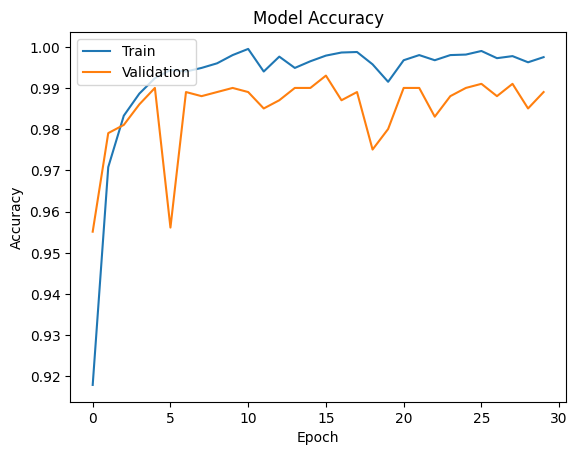

In [ ]:
# Plot training and validation accuracy over epochs
plt.plot(history.history['accuracy'])  # Accuracy on training data
plt.plot(history.history['val_accuracy'])  # Accuracy on validation data
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

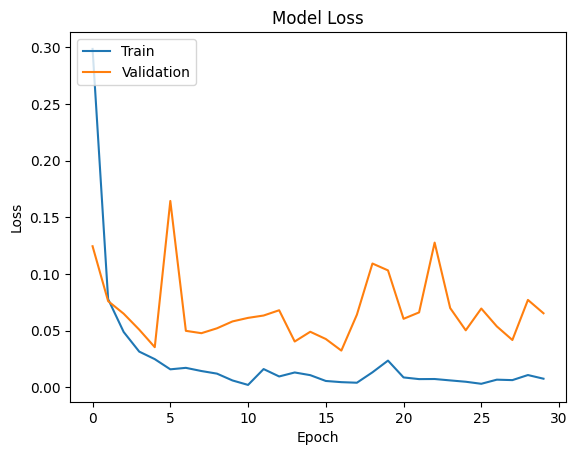

In [ ]:
# Plot training and validation loss over epochs
plt.plot(history.history['loss'])  # Loss on training data
plt.plot(history.history['val_loss'])  # Loss on validation data
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# **Section 7: Making Predictions and Evaluating on Test Data**
### This section defines a function to predict the presence of a tumor in images and evaluates the model's performance.

In [ ]:
# Define a function to predict tumor presence in a given image path
def model_prediction(im_path):
  im = cv2.imread(im_path)  # Read the image
  im = cv2.resize(im, (224,224))  # Resize the image to 224x224 pixels
  im = cv2.cvtColor(im, cv2.COLOR_RGB2BGR)  # Convert color format from RGB to BGR
  im = (im.astype(np.float32))/255  # Normalize the image pixels to [0,1]
  im = im[np.newaxis, ...]  # Add a batch dimension
  predicted = model.predict(im)  # Predict using the model
  if predicted > 0.49:
      return 1  # Return 1 if prediction is above the threshold (indicating tumor)
  if predicted < 0.50:
      return 0  # Return 0 if prediction is below the threshold (indicating no tumor)

In [ ]:
# Test the model on the test data generator
model.predict(test_generator)

16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 442ms/step


array([[0.12499082],
       [0.5827399 ],
       [0.00976192],
       ...,
       [0.999889  ],
       [0.9986865 ],
       [0.9995807 ]], dtype=float32)

In [ ]:
# Prepare lists to store real labels and predicted labels
real = []
prediction = []

# Iterate over the 'yes' tumor images in the test set
for imgs in os.listdir("/content/Dataset/test/yes"):
  real.append(1)  # Real label is 1 (tumor present)
  result = model_prediction("/content/Dataset/test/yes/" + imgs)  # Predict using the model
  prediction.append(result)  # Store the prediction

# Iterate over the 'no' tumor images in the test set
for imgs in os.listdir("/content/Dataset/test/no"):
  real.append(0)  # Real label is 0 (no tumor)
  result = model_prediction("/content/Dataset/test/no/" + imgs)  # Predict using the model
  prediction.append(result)  # Store the prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━

In [ ]:
# Convert the predictions and real labels to NumPy arrays
prediction = np.array(prediction)
real = np.array(real)

In [ ]:
# Print the classification report (precision, recall, F1-score)
print(classification_report(real, prediction))

              precision    recall  f1-score   support

           0       0.97      0.94      0.96       350
           1       0.97      0.99      0.98       652

    accuracy                           0.97      1002
   macro avg       0.97      0.96      0.97      1002
weighted avg       0.97      0.97      0.97      1002



# **Section 8: Plotting Confusion Matrix**
### This section plots the confusion matrix to visualize the model's performance on the test set.

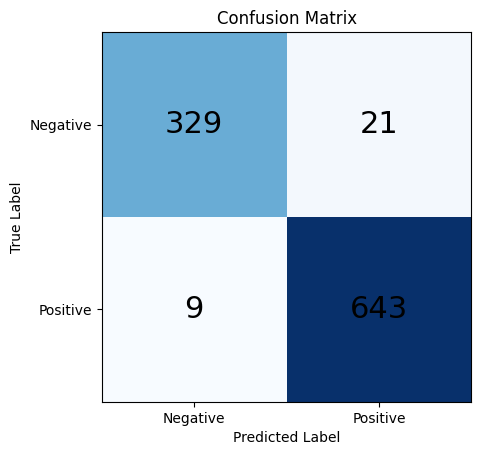

In [ ]:
# Calculate the confusion matrix
cm = confusion_matrix(real, prediction)

# Define labels for the confusion matrix
labels = ['Negative', 'Positive']

# Plot the confusion matrix
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xticks(ticks=[0,1], labels=labels)
plt.yticks(ticks=[0,1], labels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add counts to the confusion matrix
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black', fontsize=22)

plt.show()

In [ ]:
# Save the final model
model.save('tumor_ResNet50V2_mixed_data.h5')

# **Section 9: Model Evaluation on Validation Data**
### This section evaluates the model's performance on the validation set using the defined prediction function.

In [ ]:
# Reset the real and prediction lists for validation set evaluation
real = []
prediction = []

# Iterate over the 'yes' tumor images in the validation set
for imgs in os.listdir("/content/Dataset/validation/yes"):
  real.append(1)  # Real label is 1 (tumor present)
  result = model_prediction("/content/Dataset/validation/yes/" + imgs)  # Predict using the model
  prediction.append(result)  # Store the prediction

# Iterate over the 'no' tumor images in the validation set
for imgs in os.listdir("/content/Dataset/validation/no"):
  real.append(0)  # Real label is 0 (no tumor)
  result = model_prediction("/content/Dataset/validation/no/" + imgs)  # Predict using the model
  prediction.append(result)  # Store the prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━

In [ ]:
# Convert the predictions and real labels to NumPy arrays
prediction = np.array(prediction)
real = np.array(real)

In [ ]:
# Print the classification report (precision, recall, F1-score)
print(classification_report(real, prediction))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94       350
           1       0.97      0.96      0.97       653

    accuracy                           0.96      1003
   macro avg       0.95      0.96      0.95      1003
weighted avg       0.96      0.96      0.96      1003



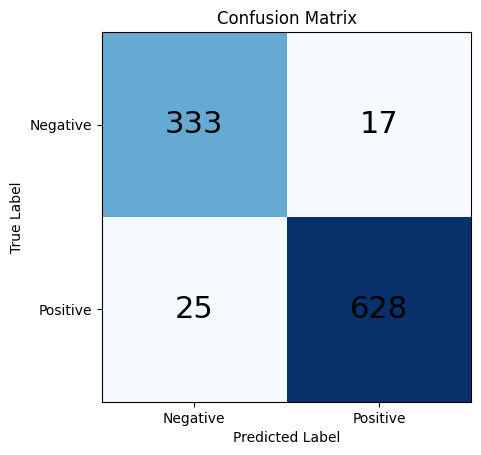

In [ ]:
# Calculate the confusion matrix for validation data
cm = confusion_matrix(real, prediction)

# Plot the confusion matrix for validation data
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xticks(ticks=[0,1], labels=labels)
plt.yticks(ticks=[0,1], labels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add counts to the confusion matrix
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black', fontsize=22)

plt.show()

# **Section 10: Test the Model on a Specific Image**
### This section demonstrates the use of the trained model to predict the presence of a tumor in a specific image.

In [ ]:
# Load the saved model for making predictions
model = tf.keras.models.load_model("/content/tumor_ResNet50V2_mixed_data.h5")

In [ ]:
# Define a function to predict tumor presence in a specific image
def model_prediction(im_path):
  im = cv2.imread(im_path)  # Read the image
  im = cv2.resize(im, (224,224))  # Resize the image to 224x224 pixels
  im = cv2.cvtColor(im, cv2.COLOR_RGB2BGR)  # Convert color format from RGB to BGR
  im = (im.astype(np.float32))/255.0  # Normalize the image pixels to [0,1]
  im = im[np.newaxis, ...]  # Add a batch dimension
  predicted = model.predict(im)  # Predict using the model
  if predicted > 0.49:
      results = "There is a tumor with a probability: " + str(predicted[0][0])
      return results
  if predicted < 0.50:
      results = "No tumor with a probability: " + str(1 - predicted[0][0])
      return results

In [ ]:
# Predict tumor presence for a specific image
model_prediction("/content/no/No12.jpg")  # Provide the path to the image you want to predict

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


'No tumor with a probability: 0.9971869164146483'